# 前期准备

让我们用最简单的例子：让电脑学习一个公式 $y = 2x$。我们先乱猜一个权重 $W=10$，看它怎么通过梯度下降变回到 $2$。

In [1]:
import numpy as np

# 1. 准备数据
x = 1.0
y_true = 2.0  # 我们的目标是让模型学会 y = 2 * x
w = 10.0      # 随机初始化的权重，现在错得很离谱
learning_rate = 0.1

print(f"开始训练，初始 W = {w}")

# 2. 模拟训练过程（下山 20 步）
for i in range(20):
    # --- 前向传播：计算目前的预测值 ---
    y_pred = w * x
    
    # --- 计算损失（均方误差的一半，方便求导）：(预测值 - 真实值)^2 ---
    loss = 0.5 * (y_pred - y_true)**2
    
    # --- 计算梯度（求导结果）：误差 * x ---
    # 这个公式是微积分算的，现在你直接拿来用就好
    gradient = (y_pred - y_true) * x
    
    # --- 梯度下降：更新权重 ---
    w = w - learning_rate * gradient
    
    if (i + 1) % 5 == 0:
        print(f"第 {i+1} 次尝试: W = {w:.4f}, 损失 = {loss:.4f}")

print(f"\n训练结束，最终 W = {w:.4f} (已经非常接近 2 了！)")


# 1. 构造数据集 (y = 5x + 30)
# 假设 100 套房子，面积在 50-150 平方
X = 2 * np.random.rand(100, 1) 
y = 30 + 5 * X + np.random.randn(100, 1) # 加点噪音，模拟真实世界的不完美

# 2. 初始化参数
w = np.random.randn(1, 1) # 随机猜一个权重
b = np.random.randn(1, 1) # 随机猜一个偏置（截距）
learning_rate = 0.1
epochs = 50 # 整个数据集看 50 遍

# 3. 开始训练
for epoch in range(epochs):
    # 这里我们用的是简化的全量计算，感受逻辑
    y_pred = X.dot(w) + b
    
    # 计算误差
    error = y_pred - y
    
    # 计算梯度 (求导的结果)
    grad_w = (2/100) * X.T.dot(error)
    grad_b = (2/100) * np.sum(error)
    
    # 更新参数
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b
    
    if epoch % 10 == 0:
        loss = np.mean(error**2)
        print(f"Epoch {epoch}: Loss = {loss:.4f}, w = {w[0][0]:.2f}, b = {b[0][0]:.2f}")

print(f"\n最终模型: 房价 = {w[0][0]:.2f} * 面积 + {b[0][0]:.2f}")



开始训练，初始 W = 10.0
第 5 次尝试: W = 6.7239, 损失 = 13.7750
第 10 次尝试: W = 4.7894, 损失 = 4.8030
第 15 次尝试: W = 3.6471, 损失 = 1.6747
第 20 次尝试: W = 2.9726, 损失 = 0.5839

训练结束，最终 W = 2.9726 (已经非常接近 2 了！)
Epoch 0: Loss = 985.8083, w = 7.98, b = 8.40
Epoch 10: Loss = 30.6924, w = 13.60, b = 19.73
Epoch 20: Loss = 16.6265, w = 11.28, b = 22.53
Epoch 30: Loss = 9.2142, w = 9.57, b = 24.55
Epoch 40: Loss = 5.3054, w = 8.33, b = 26.02

最终模型: 房价 = 7.50 * 面积 + 27.00


# 2.Sklearn初步使用

## 🛠️ 第一站：Sklearn 的“三板斧”工作流
不管多么复杂的算法（回归、决策树、SVM），在 Sklearn 里的操作逻辑几乎是完全统一的。你只需要记住这三个动作：

实例化 (Instantiate)：选好工具。比如：“我要用线性回归模型”。

拟合 (Fit)：喂数据。也就是我们之前手写的 epochs 循环，Sklearn 在这一步自动帮你做了。

预测 (Predict)：出结果。把新数据丢给训练好的模型。

## 💻 第二站：工业级代码实战（房价预测）
我们将不再手动写导数和循环，看看用 Sklearn 如何实现。

1. 准备数据
在 AI 工程中，数据通常分为 特征 (X) 和 标签 (y)。

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression #导入线性回归类
import matplotlib.pyplot as plt

#模拟数据：面积（x） 和 价格（y）
X = np.array([[50],[70],[90],[110],[130]])
y = np.array([150,210,265,330,395])     #目标房价

# 第一步：实例化（买个打火机）
model = LinearRegression()

# 第二步：拟合（把燃料和火石放进去训练）
# 这一步模型会自动帮你计算出最合适的 w 和 b
model.fit(X, y)

# 第三步：预测（打火看效果）
x_new = [[100]] # 我想预测 100 平米的房子多少钱
prediction = model.predict(x_new)

print(f"100平米的预测价格是: {prediction[0]:.2f} 万")

print(f"模型学到的权重(w): {model.coef_[0]:.2f}")
print(f"模型学到的截距(b): {model.intercept_:.2f}")



100平米的预测价格是: 300.50 万
模型学到的权重(w): 3.05
模型学到的截距(b): -4.50


## 📈 第三站：如何评价模型好坏？（R² 分数）
光预测出来还不行，老板会问你：“你的模型准不准？”在回归问题中，最通用的指标是 $R^2$ (决定系数)。生活化类比：满分 100 分。如果 $R^2 = 0.95$，说明你的模型解释了 95% 的数据变动，非常优秀。如果 $R^2 = 0.2$，那说明你的模型跟瞎猜差不多。


In [3]:

score = model.score(X,y)
print(f"模型准确度（R^2）:{score:.4f}")

## 多变量线性回归

from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([
    [50,0.5],
    [70,1.2],
    [90,0.2],
    [110,2.5],
    [130,1.0]
])

y = np.array([150,210,265,330,395])

model = LinearRegression()
model.fit(X,y)

print(f"学到的权重（面积，距离）：{model.coef_}")
print(f"学到的截距：{model.intercept_:.2f}")

# 预测：100平米，距离地铁 0.8公里的房子
test_house = [[100, 0.8]]
pred = model.predict(test_house)
print(f"预测价格: {pred[0]:.2f} 万")



模型准确度（R^2）:0.9989
学到的权重（面积，距离）：[3.04253532 0.64910271]
学到的截距：-4.53
预测价格: 300.24 万


# 3.数据预处理

## 第一招：特征缩放（Feature Scaling）—— 消除“贫富差距”
如果一个特征数值很大（如年收入 100,000），另一个很小（如家庭人口 3），梯度下降时会像在一个狭长的山谷里跳动，很难收敛。

标准化 (StandardScaler)：把数据变成均值为 0，方差为 1 的分布。这是最常用的方法。

## 第二招：缺失值处理 (Imputation) —— 填补“坑洞”
简单暴力：直接删掉那一行（如果数据量够大）。

稳健做法：用平均值、中位数去填补。

## 第三招：独热编码 (One-Hot Encoding) —— 让电脑读懂文字
如果“朝向”有三种：朝东、朝西、朝南。我们不能给它们编成 1, 2, 3，因为 3 比 1 大，但“朝南”并不比“朝东”大。

做法：变成三列（是否朝东、是否朝西、是否朝南），是就填 1，不是就填 0。

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. 模拟一组“脏”数据
data = {
    '面积': [100, 80, np.nan, 120], # 存在一个缺失值 nan
    '距离': [0.5, 1.2, 0.8, 3.0]
}
df = pd.DataFrame(data)

# --- 处理缺失值 ---
# 实例化：告诉它我们要用“平均值”填坑
imputer = SimpleImputer(strategy='mean')
# 拟合 + 转换
X_filled = imputer.fit_transform(df)
print("填补后的数据：\n", X_filled)

# --- 特征缩放（标准化） ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)
print("\n标准化后的数据（数值都在一个小范围内）：\n", X_scaled)



# --- 核心：你必须先定义 X 和 y ---
# 假设我们有 10 套房子的数据
X = np.array([[50], [60], [70], [80], [90], [100], [110], [120], [130], [140]])
y = np.array([100, 120, 145, 160, 185, 210, 230, 255, 280, 310])

# 现在再运行这行代码，电脑就不会报错了
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("训练集大小:", len(X_train))
print("测试集大小:", len(X_test))





填补后的数据：
 [[100.    0.5]
 [ 80.    1.2]
 [100.    0.8]
 [120.    3. ]]

标准化后的数据（数值都在一个小范围内）：
 [[ 0.         -0.90159484]
 [-1.41421356 -0.18031897]
 [ 0.         -0.59247661]
 [ 1.41421356  1.67439042]]
训练集大小: 8
测试集大小: 2


## 📝 知识点笔记卡片
标准化：消除不同单位（如平米 vs 公里）带来的数值差异，让模型跑得更稳。

独热编码：把文字分类变成 0 和 1。

train_test_split：机器学习的“闭卷考试”机制。

# 4.逻辑回归

In [6]:
from sklearn.linear_model import LogisticRegression
import numpy as np

from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. 准备数据：[大小, 硬度]
X = np.array([
    [1, 2], [2, 1], [2, 3],   # 较小、较软（通常是良性）
    [5, 8], [6, 7], [8, 9]    # 较大、较硬（通常是恶性）
])
# 标签：0 是良性，1 是恶性
y = np.array([0, 0, 0, 1, 1, 1])

# 2. 实例化并训练
# 逻辑回归虽然叫 Regression，但它在 Sklearn 里是分类器
clf = LogisticRegression() 
clf.fit(X, y)

# 3. 预测新病例
new_patient = np.array([[6, 6]]) # 一个肿瘤大小6，硬度6的病人
prediction = clf.predict(new_patient)
probability = clf.predict_proba(new_patient) # 查看概率

print(f"预测结果: {'恶性' if prediction[0]==1 else '良性'}")
print(f"良性概率: {probability[0][0]:.2f}, 恶性概率: {probability[0][1]:.2f}")



预测结果: 恶性
良性概率: 0.13, 恶性概率: 0.87


# 5.决策树and随机森林min

预测结果: 恶性
良性概率: 0.13, 恶性概率: 0.87
训练集准确率: 0.99
测试集准确率: 0.94


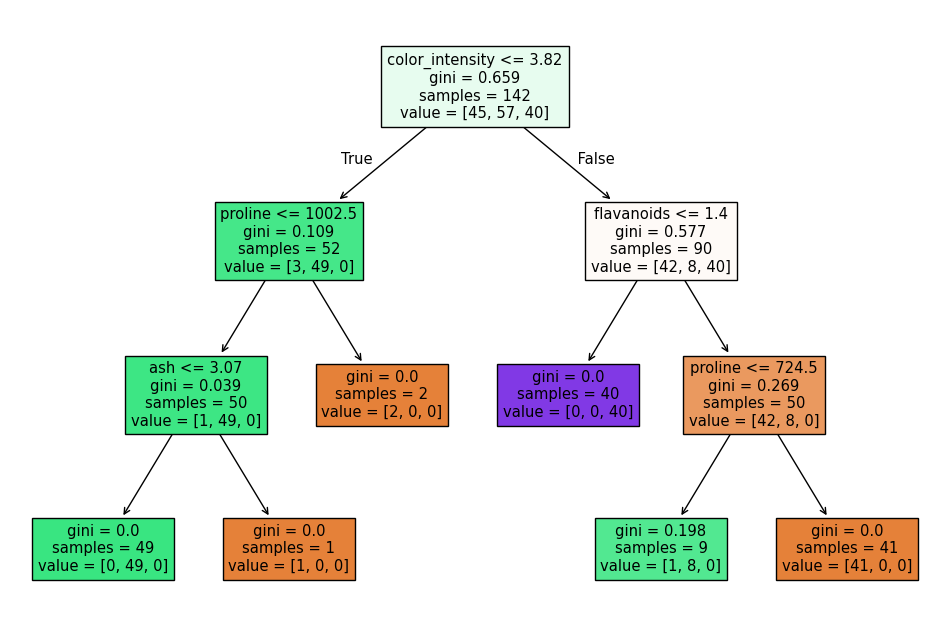

随机森林测试集准确率: 1.00


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# 1. 逻辑回归（肿瘤分类）
X = np.array([
    [1, 2], [2, 1], [2, 3],   
    [5, 8], [6, 7], [8, 9]    
])
y = np.array([0, 0, 0, 1, 1, 1])

clf = LogisticRegression() 
clf.fit(X, y)

new_patient = np.array([[6, 6]])
prediction = clf.predict(new_patient)
probability = clf.predict_proba(new_patient)

print(f"预测结果: {'恶性' if prediction[0]==1 else '良性'}")
print(f"良性概率: {probability[0][0]:.2f}, 恶性概率: {probability[0][1]:.2f}")

# 2. 决策树（红酒分类）
wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

print(f"训练集准确率: {clf.score(X_train, y_train):.2f}")
print(f"测试集准确率: {clf.score(X_test, y_test):.2f}")

plt.figure(figsize=(12, 8))
tree.plot_tree(clf, filled=True, feature_names=wine.feature_names)
plt.show()

# 3. 随机森林
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X_train, y_train)
print(f"随机森林测试集准确率: {rf.score(X_test, y_test):.2f}")

# 6. 泰坦尼克号生还者预测 (Titanic Survival Prediction)

   Pclass     Sex   Age  SibSp   Fare  Survived
0       3    male  22.0      1   7.25         0
1       1  female  38.0      1  71.28         1
2       3  female  26.0      0   7.92         1
3       1  female  35.0      1  53.10         1
4       3    male   NaN      0   8.05         0
训练集准确率: 1.00


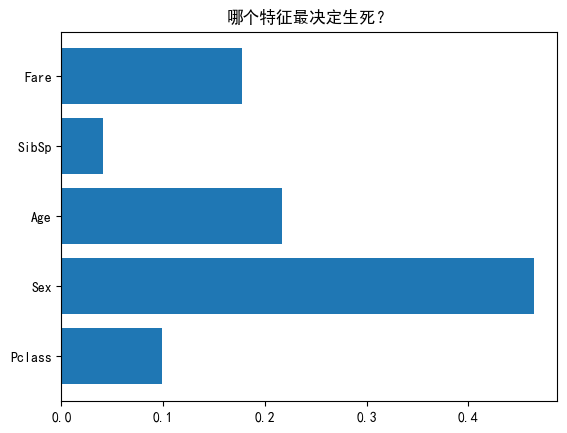

In [8]:
import pandas as pd
import numpy as np

#模拟加载数据（真实场景用pd.read_csv）
data = {
    'Pclass':[3,1,3,1,3],         #舱位等级（1 = 头等，3 = 三等）
    'Sex':['male','female','female','female','male'],
    'Age':[22,38,26,35,np.nan],
    'SibSp':[1,1,0,1,0],           #兄弟姐妹/配偶人数
    'Fare':[7.25,71.28,7.92,53.10,8.05],   #票价
    'Survived':[0,1,1,1,0]        #结果：生还（1），遇难（0）
}
df = pd.DataFrame(data)
print(df.head())

#我们用年龄的中位数来填补那个 nan。
df['Age'] = df['Age'].fillna(df['Age'].median())

#既然性别只有男女，我们直接把 female 变成 1，male 变成 0。
df['Sex'] = df['Sex'].map({'female':1,'male':0})

### 随机森林

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 准备特征 X 和标签 y
X = df.drop('Survived',axis=1)
y = df['Survived']

#切分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#实例化并训练
model = RandomForestClassifier(n_estimators=100, max_depth = 5)
model.fit(X_train, y_train)

# 查看效果
print(f"训练集准确率: {model.score(X_train, y_train):.2f}")

import matplotlib.pyplot as plt

# 获取每个特征的分数
importances = model.feature_importances_
features = X.columns

# 绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.barh(features, importances)
plt.title("哪个特征最决定生死？")
plt.show()

